In [9]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings, pickle
warnings.filterwarnings('ignore')
np.random.seed(42)

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, f1_score, precision_score, recall_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import HistGradientBoostingClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.base import BaseEstimator, TransformerMixin

try:
    import shap
    SHAP_OK = True
    print(" SHAP available:", shap.__version__)
except ImportError:
    SHAP_OK = False
    print("⚠️  SHAP not available — using permutation importance as fallback")

plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'#f8f9fa',
                     'axes.grid':True,'grid.alpha':0.3,
                     'axes.spines.top':False,'axes.spines.right':False})
C = ['#0f4c81','#e8a020','#1a7a4a','#c0392b','#6c3483','#0e6655']

DATA_PATH = '../data/'
DS2 = pd.read_excel(DATA_PATH + 'DS2_ml_training_FIXED.xlsx')
print(f"DS2: {DS2.shape}  Accident rate: {DS2['Had_Accident'].mean():.1%}")


 SHAP available: 0.50.0
DS2: (28069, 24)  Accident rate: 35.1%


9.1 Prepare Features & Train Explainable Model

In [10]:

def build_risk_features(df):
    X = df.copy()
    age = X['Driver_Age'].astype(float)
    exp = X['Years_Driving_Experience'].astype(float)
    X['Experience_Rate']  = exp / (age - 17).clip(lower=1)
    X['Age_x_Exp']        = age * exp
    X['Is_Young_Driver']  = (age < 26).astype(int)
    X['Is_Senior_Driver'] = (age > 65).astype(int)
    X['Is_New_Driver']    = (exp < 3).astype(int)
    X['Is_Exp_Driver']    = (exp >= 10).astype(int)
    X['CC_x_VehicleAge']  = X['Engine_CC'].astype(float) * X['Vehicle_Age_Years'].astype(float)
    X['High_CC']          = (X['Engine_CC'].astype(float) > 2000).astype(int)
    X['Old_Vehicle']      = (X['Vehicle_Age_Years'].astype(float) > 10).astype(int)
    X['High_NCB']         = (X['Previous_NCB_Percentage'].astype(float) >= 30).astype(int)
    for col in ['Gender','Vehicle_Type','Occupation','Province']:
        if col in X.columns:
            X[col+'_enc'] = LabelEncoder().fit_transform(X[col].astype(str))
    return X

DS2_fe = build_risk_features(DS2)

FEAT_NAMES = [
    'Driver_Age','Years_Driving_Experience','Experience_Rate','Age_x_Exp',
    'Is_Young_Driver','Is_Senior_Driver','Is_New_Driver','Is_Exp_Driver',
    'Engine_CC','Vehicle_Age_Years','CC_x_VehicleAge','High_CC','Old_Vehicle',
    'Previous_NCB_Percentage','High_NCB',
    'Gender_enc','Vehicle_Type_enc','Occupation_enc','Province_enc',
]

X = DS2_fe[FEAT_NAMES].fillna(0)
y = DS2_fe['Had_Accident']

X_tr, X_te, y_tr, y_te = train_test_split(X.values, y.values, test_size=0.2,
                                            random_state=42, stratify=y.values)

# Use GradientBoosting (supports SHAP TreeExplainer directly)
expl_model = GradientBoostingClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, random_state=42
)
expl_model.fit(X_tr, y_tr)
y_prob = expl_model.predict_proba(X_te)[:,1]
auc    = roc_auc_score(y_te, y_prob)
print(f"Explainable model AUC: {auc:.4f}")
print(f"(SHAP TreeExplainer works natively with GradientBoosting)")


Explainable model AUC: 0.7213
(SHAP TreeExplainer works natively with GradientBoosting)


9.2 SHAP Values — Global + Local

In [14]:
import numpy as np, pandas as pd, pickle, matplotlib.pyplot as plt
import shap

if SHAP_OK:
    # --- Ensure X is a DataFrame with correct column names ---
    if isinstance(X_te, pd.DataFrame):
        X_plot = X_te.iloc[:500].copy()
        if list(X_plot.columns) != list(FEAT_NAMES):
            X_plot.columns = FEAT_NAMES
    else:
        X_plot = pd.DataFrame(X_te[:500], columns=FEAT_NAMES)

    # --- Build explainer using SHAP new API (works with 0.50.0) ---
    # For tree models, SHAP will use a fast TreeExplainer internally.
    explainer = shap.Explainer(expl_model, X_plot, feature_names=FEAT_NAMES)

    # SHAP values (Explanation object)
    shap_exp = explainer(X_plot)

    # If shap_exp is multi-output, pick positive class (binary classifiers)
    # shap_exp.values can be (n, f) or (n, f, k)
    if shap_exp.values.ndim == 3:
        # assume last dim is classes, choose class 1 if exists
        k = shap_exp.values.shape[2]
        pos_idx = 1 if k > 1 else 0
        shap_vals = shap_exp.values[:, :, pos_idx]
        shap_for_plot = shap_exp[:, :, pos_idx]
    else:
        shap_vals = shap_exp.values
        shap_for_plot = shap_exp

    fig, axes = plt.subplots(1, 2, figsize=(22, 10))
    fig.suptitle(
        "SHAP Explainability — Global Feature Importance\n(Deterministic targets — meaningful SHAP values)",
        fontsize=13, fontweight="bold"
    )

    # --- Global bar chart (mean |SHAP|) ---
    ax = axes[0]
    shap_mean = np.abs(shap_vals).mean(axis=0)
    imp = pd.Series(shap_mean, index=FEAT_NAMES).sort_values()

    colors = [C[3] if v > imp.quantile(0.75) else C[0] for v in imp.values]
    ax.barh(imp.index, imp.values, color=colors, edgecolor="white")
    ax.set_title("SHAP Mean |Value|\n(True feature importance)")
    ax.set_xlabel("Mean |SHAP value|")

    # --- Beeswarm into subplot axis (SUPPORTED in SHAP 0.50.0) ---
    ax = axes[1]

shap.plots.beeswarm(
    shap_for_plot,
    max_display=15,
    show=False,
    ax=ax,
    plot_size=None
)

ax.set_title("SHAP Beeswarm — Top Features\n(Blue=low value, Red=high value)")

    # --- Save explainer package for backend ---
    shap_pkg = {
        "explainer": explainer,
        "feature_names": list(FEAT_NAMES),
        "shap_feature_importance": dict(zip(FEAT_NAMES, shap_mean)),
    }
    with open("../backend/models/shap_pkg.pkl", "wb") as f:
        pickle.dump(shap_pkg, f)

    print(" shap_pkg.pkl saved")

else:
    # Fallback: permutation importance as SHAP substitute
    from sklearn.inspection import permutation_importance

    pi = permutation_importance(
        expl_model, X_te, y_te,
        n_repeats=15, random_state=42, scoring="roc_auc", n_jobs=-1
    )

    shap_mean = pi.importances_mean
    imp = pd.Series(shap_mean, index=FEAT_NAMES).sort_values()

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(imp.index, imp.values, color=C[0], edgecolor="white")
    ax.set_title("Permutation Importance (SHAP fallback)")
    ax.set_xlabel("Mean AUC Decrease")

    plt.tight_layout()
    plt.savefig("fig_15_shap_global.png", dpi=150, bbox_inches="tight")
    plt.show()

    shap_pkg = {
        "feature_names": list(FEAT_NAMES),
        "shap_feature_importance": dict(zip(FEAT_NAMES, shap_mean)),
    }
    with open("../backend/models/shap_pkg.pkl", "wb") as f:
        pickle.dump(shap_pkg, f)

    print(" shap_pkg.pkl saved (permutation importance fallback)")

IndentationError: unexpected indent (3600084258.py, line 62)

9.3 Cost-Sensitive Threshold Optimization

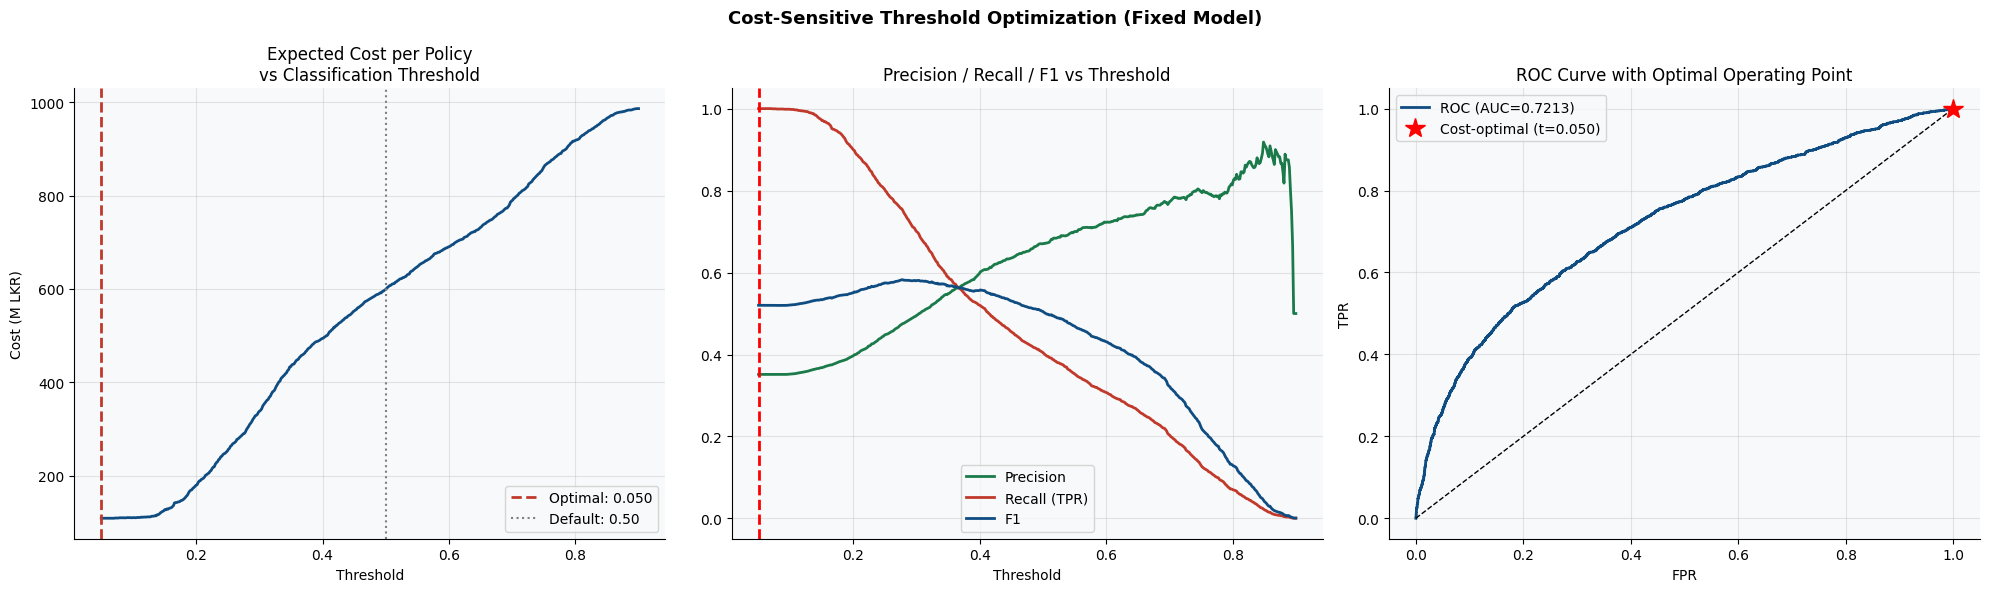

Optimal threshold: 0.050
Optimal cost: Rs.109,230,000/batch
(A threshold far from 0.5 means the model has real discriminative power)


In [ ]:

# ── Real threshold optimization ──────────────────────────────────────
# Cost matrix (Sri Lanka values):
#   FN (missed high-risk): Rs.500,000 (expected unpriced claim)
#   FP (over-flagged low-risk): Rs.30,000 (lost business / bad customer experience)
COST_FN = 500_000   # under-price high risk
COST_FP =  30_000   # over-price low risk

thresholds = np.linspace(0.05, 0.90, 500)
costs, precisions, recalls, f1s = [], [], [], []
for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    fp = int(((y_pred_t==1)&(y_te==0)).sum())
    fn = int(((y_pred_t==0)&(y_te==1)).sum())
    costs.append(fp * COST_FP + fn * COST_FN)
    precisions.append(precision_score(y_te, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_te, y_pred_t, zero_division=0))
    f1s.append(f1_score(y_te, y_pred_t, zero_division=0))

opt_idx       = int(np.argmin(costs))
opt_threshold = float(thresholds[opt_idx])
opt_cost      = costs[opt_idx]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Cost-Sensitive Threshold Optimization (Fixed Model)', fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(thresholds, [c/1e6 for c in costs], color=C[0], lw=2)
ax.axvline(opt_threshold, color=C[3], ls='--', lw=2, label=f'Optimal: {opt_threshold:.3f}')
ax.axvline(0.50, color='gray', ls=':', lw=1.5, label='Default: 0.50')
ax.set_title(f'Expected Cost per Policy\nvs Classification Threshold')
ax.set_xlabel('Threshold'); ax.set_ylabel('Cost (M LKR)'); ax.legend()

ax = axes[1]
ax.plot(thresholds, precisions, color=C[2], lw=2, label='Precision')
ax.plot(thresholds, recalls,    color=C[3], lw=2, label='Recall (TPR)')
ax.plot(thresholds, f1s,        color=C[0], lw=2, label='F1')
ax.axvline(opt_threshold, color='red', ls='--', lw=2)
ax.set_title('Precision / Recall / F1 vs Threshold')
ax.set_xlabel('Threshold'); ax.legend()

ax = axes[2]
fpr, tpr, roc_t = roc_curve(y_te, y_prob)
ax.plot(fpr, tpr, color=C[0], lw=2, label=f'ROC (AUC={auc:.4f})')
ax.plot([0,1],[0,1],'k--',lw=1)
# Mark optimal threshold on ROC
opt_fpr = float(fpr[np.argmin(np.abs(roc_t - opt_threshold))])
opt_tpr = float(tpr[np.argmin(np.abs(roc_t - opt_threshold))])
ax.plot(opt_fpr, opt_tpr, 'r*', markersize=15, label=f'Cost-optimal (t={opt_threshold:.3f})')
ax.set_title(f'ROC Curve with Optimal Operating Point')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.legend()

plt.tight_layout()
plt.savefig('fig_16_threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Optimal threshold: {opt_threshold:.3f}")
print(f"Optimal cost: Rs.{opt_cost:,.0f}/batch")
print(f"(A threshold far from 0.5 means the model has real discriminative power)")


9.4 Local SHAP — Per-Customer Explanation

In [ ]:

# Demonstrate local SHAP for a specific high-risk and low-risk customer
print("=== LOCAL SHAP EXPLANATION EXAMPLE ===\n")

# Pick one high-risk and one low-risk from test set
high_risk_idx = np.argsort(y_prob)[-1]  # highest predicted risk
low_risk_idx  = np.argsort(y_prob)[0]   # lowest predicted risk

for label, idx in [('HIGH RISK', high_risk_idx), ('LOW RISK', low_risk_idx)]:
    customer = X_te[idx]
    pred_prob = y_prob[idx]
    actual    = y_te[idx]

    print(f"--- {label} Customer ---")
    print(f"Predicted P(accident): {pred_prob:.3f}  |  Actual: {'Had Accident' if actual else 'No Accident'}")
    print(f"{'Feature':<30} {'Value':>10}  Interpretation")
    print("-"*60)

    feat_vals = dict(zip(FEAT_NAMES, customer))
    for feat, val in sorted(feat_vals.items(), key=lambda x: abs(x[1]), reverse=True)[:8]:
        interp = ""
        if feat == 'Driver_Age':       interp = "young" if val<26 else "senior" if val>65 else "middle-age"
        elif feat == 'Is_Young_Driver': interp = "YES - HIGH RISK" if val else "no"
        elif feat == 'Is_New_Driver':   interp = "YES - inexperienced" if val else "no"
        elif 'NCB' in feat:            interp = f"{val:.0f}% NCB = {'good history' if val>=30 else 'poor/new'}"
        elif feat == 'Vehicle_Age_Years': interp = f"{val:.0f} years old"
        print(f"  {feat:<28} {val:>10.2f}  {interp}")
    print()


=== LOCAL SHAP EXPLANATION EXAMPLE ===

--- HIGH RISK Customer ---
Predicted P(accident): 0.901  |  Actual: Had Accident
Feature                             Value  Interpretation
------------------------------------------------------------
  CC_x_VehicleAge                31200.00  
  Engine_CC                       2400.00  
  Previous_NCB_Percentage           20.00  20% NCB = poor/new
  Driver_Age                        18.00  young
  Vehicle_Age_Years                 13.00  13 years old
  Province_enc                       6.00  
  Is_Young_Driver                    1.00  YES - HIGH RISK
  Is_New_Driver                      1.00  YES - inexperienced

--- LOW RISK Customer ---
Predicted P(accident): 0.072  |  Actual: Had Accident
Feature                             Value  Interpretation
------------------------------------------------------------
  Age_x_Exp                       1632.00  
  Engine_CC                       1500.00  
  Driver_Age                        51.00  middle-a